<a href="https://colab.research.google.com/github/lnghan/MC311-Analysis/blob/main/3-analysis/notebooks/le_capstone_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Han Le
# DATA 205 Project EDA Part



---



In [1]:
# Upload cleaned datasets (MC311 + ZIP Code)

from google.colab import files
uploaded = files.upload()

Saving zip_codes_clean.csv to zip_codes_clean.csv
Saving mc311_weather_clean.csv to mc311_weather_clean.csv


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.colors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_absolute_error

In [3]:
mc311 = pd.read_csv('mc311_weather_clean.csv')
zips = pd.read_csv('zip_codes_clean.csv')

In [7]:
merged = pd.merge(mc311, zips, on='city_name', how='left')

# Remove duplicate zip_code column
merged = merged.drop(columns=['zip_code_y'])
merged = merged.rename(columns={'zip_code_x': 'zip_code'})

In [48]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10397 entries, 0 to 10396
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     10397 non-null  int64  
 1   date_opened            10397 non-null  object 
 2   date_closed            10203 non-null  object 
 3   status                 10397 non-null  object 
 4   response_time          10203 non-null  float64
 5   sla_days               10396 non-null  float64
 6   within_sla             10397 non-null  object 
 7   zip_code               10397 non-null  int64  
 8   city_name              10397 non-null  object 
 9   department             10397 non-null  object 
 10  area                   10397 non-null  object 
 11  area_topic             10396 non-null  object 
 12  date                   10358 non-null  object 
 13  prcp                   10358 non-null  float64
 14  max_temp               10358 non-null  float64
 15  mi



---



#**Multiple Regression Model with Response Time as Target**

In [66]:
# Make a copy of dataset for safe measures
copy = merged.copy()
features = ['sla_days', 'population', 'avg_temp', 'med_household_income', 'med_individual_income', 'housing_units', 'white', 'black', 'american_indian', 'non_hispanic_other', 'hispanic', 'asian', 'native_hawaiian', 'med_age']

# Drop rows with NaN values in the relevant columns before creating X and y
copy = copy.dropna(subset=features + ['response_time'])

X = copy[features]
y = copy['response_time']

In [67]:
# Add a constant to the independent variables for OLS regression
X_ols = sm.add_constant(X)

# Multiple Regression Model
ols_model = sm.OLS(y, X_ols)
ols_results = ols_model.fit()

print(ols_results.summary())

                            OLS Regression Results                            
Dep. Variable:          response_time   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     244.5
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          5.93e-293
Time:                        02:46:09   Log-Likelihood:                -40845.
No. Observations:               10142   AIC:                         8.170e+04
Df Residuals:                   10135   BIC:                         8.175e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  6.907e-

Only 12.6% (R-squared is 0.126) of the variance in response time is explained these predictors are not major indicators of how quick/slow the response time for MC311 requests are. The dataset is most likely too messy and would require context such as workload, staffing levels, complexity of the request, other conditions, to better explain variation in response times.

SLA days is the only variable that shows a moderate relationship with response time. All the demographic, economic, and environmental variables are not statistically significant and they have extremely small coeffiecints. The results also show signs of potential multicollinearity and non-normality.



---



##**Classification Model with SLA Compliance**

In [80]:
classification = merged.copy()

# Convert Yes/No -> 1/0
classification['within_sla'] = classification['within_sla'].map({'Yes': 1, 'No': 0})

class_features = ['response_time',
            'sla_days',
            'prcp',
            'avg_temp',
            'med_household_income',
            'population']

classification = classification.dropna(subset=class_features + ['within_sla'])
X_class = classification[class_features]
y_class = classification['within_sla']

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

In [81]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.76      0.81       200
           1       0.97      0.99      0.98      1829

    accuracy                           0.97      2029
   macro avg       0.93      0.87      0.90      2029
weighted avg       0.96      0.97      0.96      2029



In [79]:
importance = pd.DataFrame({'Feature': features,'Coefficient': model.coef_[0]}).sort_values(by='Coefficient', ascending=False)

importance

,Feature,Coefficient
1,sla_days,4.390214
3,avg_temp,0.024832
5,population,0.000010
4,med_household_income,0.000006
2,prcp,-0.013133
0,response_time,-3.018038


The model has 97% accuracy, however, it is most likely beacuse the dataset is imbalanced, as there are significantly more Yes SLA cases than No SLA cases. The model performs much better on for Yes (F1 = 0.98) compared to No (F1 = 0.81).

It is highly effective at identifying Yes SLA cases, but with the recall of 0.76, it is less reliable in detecting No SLA cases.

So despite strong accuracy, the model definitely has a bias toward Yes SLA since there are way more records than No SLA.



---



## **Correlation Matrix to see if there's any strong correlations I want to explore**

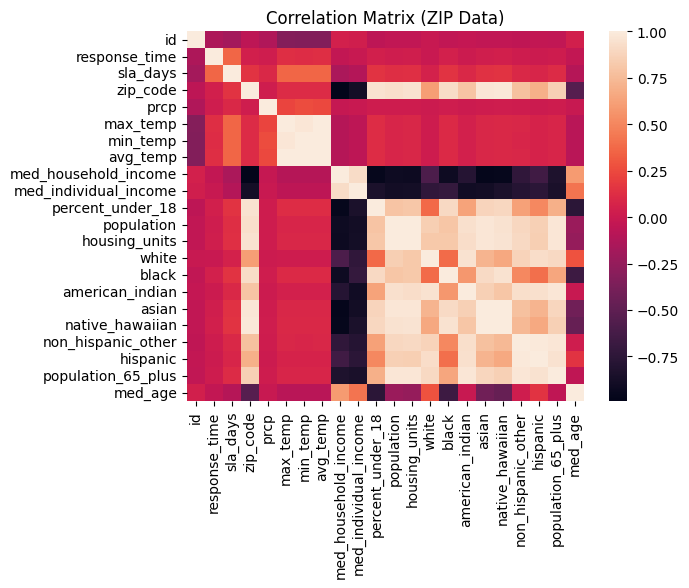

In [8]:
numeric_cols = merged.select_dtypes(include='number')
corr = numeric_cols.corr()

sns.heatmap(corr, annot=False)
plt.title("Correlation Matrix")
plt.show()

Nothing that isn't already self-explanatory



---



##**Analyzing if city impacts SLA compliance**

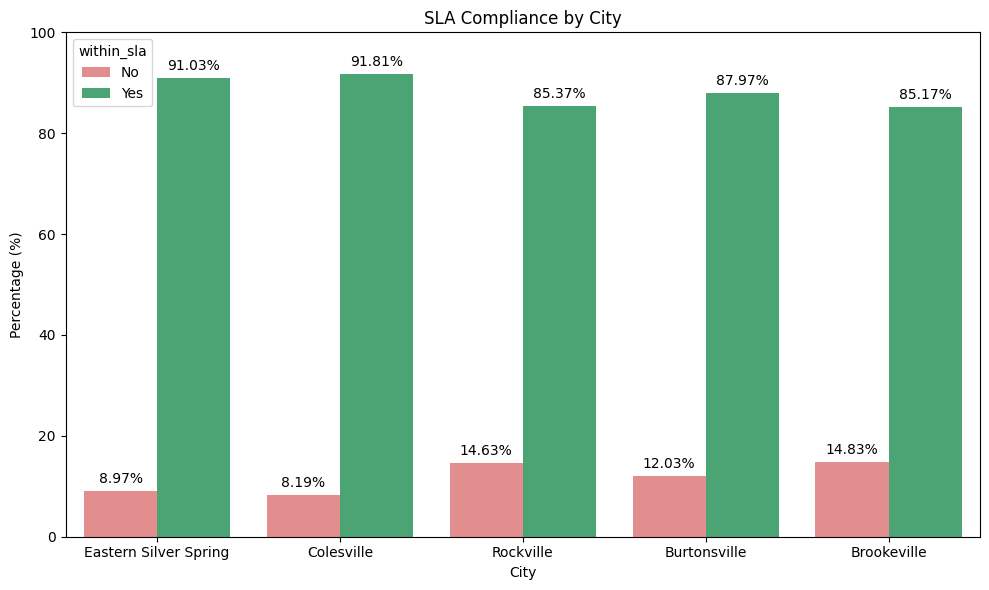

In [68]:
# Calculate counts for within_sla status per city and percentages for labels
sla_status_counts = mc311.groupby(['city_name', 'within_sla']).size().unstack(fill_value=0)
sla_percentages = sla_status_counts.apply(lambda x: x / x.sum() * 100, axis=1).reset_index()

# Melt for plotting
sla_percentages_melted = sla_percentages.melt(id_vars='city_name', var_name='within_sla', value_name='percentage')

plt.figure(figsize=(10, 6))
sns.barplot(data=sla_percentages_melted,
            x='city_name',
            y='percentage',
            hue='within_sla',
            palette={'Yes': 'mediumseagreen',
                     'No': 'lightcoral'},
            order=mc311['city_name'].value_counts().index)
plt.title('SLA Compliance by City')
plt.xlabel('City')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)

# Add labels to bars
for container in plt.gca().containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            plt.gca().text(bar.get_x() + bar.get_width() / 2, height + 1,
                           f'{height:.2f}%', ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()

No



---



##**Over Time Analyses**

In [ ]:
daily_counts = mc311.groupby('date').size().reset_index(name='count')

fig = px.line(daily_counts, x='date', y='count', title="Requests Over Time")
fig.show()

In [ ]:
requests_by_area_over_time = mc311.groupby(['date', 'area']).size().reset_index(name='count')

fig = px.line(requests_by_area_over_time, x='date', y='count', color='area',
              title='Requests Over Time by Service Area')
fig.update_layout(xaxis_title='Date', yaxis_title='Number of Requests')
fig.show()

In [ ]:
highway_services_requests = mc311[mc311['area'] == 'Highway Services']

# Get the top 5 area_topics for Highway Services
top_5_highway_area_topics = highway_services_requests['area_topic'].value_counts().head(5).index.tolist()

# Filter the highway_services_requests to include only these top 5 topics
highway_services_top_5_topics = highway_services_requests[highway_services_requests['area_topic'].isin(top_5_highway_area_topics)]

# Group by date and area_topic to get counts over time
requests_by_area_topic_over_time = highway_services_top_5_topics.groupby(['date', 'area_topic']).size().reset_index(name='count')

# Convert the 'date' column to datetime objects
requests_by_area_topic_over_time['date'] = pd.to_datetime(requests_by_area_topic_over_time['date'])

# Filter for data in 2026
requests_2026_only = requests_by_area_topic_over_time[requests_by_area_topic_over_time['date'].dt.year == 2026]

# Create the Plotly line chart
fig = px.line(requests_2026_only, x='date', y='count', color='area_topic',
              title='Top 5 Highway Services Request Types Over Time (2026 Only)')
fig.update_layout(xaxis_title='Date', yaxis_title='Number of Requests')
fig.show()

In [ ]:
# Group requests by date and city name, and count them
requests_by_date_city = merged.groupby(['date', 'city_name']).size().reset_index(name='count')

# Get unique city names to ensure all cities are considered for merging income data
unique_cities = requests_by_date_city['city_name'].unique()

# Select income columns from the original 'zips' DataFrame for merging
income_data = zips[['city_name', 'med_household_income', 'med_individual_income']].drop_duplicates()

# Merge the request counts with income data based on city_name
requests_by_date_city_income = pd.merge(requests_by_date_city, income_data, on='city_name', how='left')

# Convert 'date' column to datetime type for filtering
requests_by_date_city_income['date'] = pd.to_datetime(requests_by_date_city_income['date'])

# Filter for data in 2026 only
requests_2026_only = requests_by_date_city_income[requests_by_date_city_income['date'].dt.year == 2026]

# Create the Plotly line chart
fig = px.line(requests_2026_only,
              x='date',
              y='count',
              color='city_name',
              title='Requests Over Time by City Name with Income on Hover (2026 Only)',
              hover_data=['med_household_income', 'med_individual_income'])

fig.update_layout(xaxis_title='Date', yaxis_title='Number of Requests')
fig.show()

In [73]:
all_unique_area_topics = merged['area_topic'].dropna().unique()

# Create a color map for all unique area_topics so they're the same color in each graph
colors = plotly.colors.qualitative.Dark24
color_map = {topic: colors[i % len(colors)] for i, topic in enumerate(all_unique_area_topics)}

for city in unique_cities:
    city_data = merged[merged['city_name'] == city]
    # Calculate top 10 area_topics for the current city
    top_10_area_topics = city_data['area_topic'].value_counts().head(10).index.tolist()
    # Filter city data to include only top 10 area_topics
    city_top_topics_data = city_data[city_data['area_topic'].isin(top_10_area_topics)]
    # Group by date and area_topic to get counts over time
    requests_by_date_topic = city_top_topics_data.groupby(['date', 'area_topic']).size().reset_index(name='count')

    # Plot
    fig = px.line(requests_by_date_topic,
                  x='date',
                  y='count',
                  color='area_topic',
                  title=f'Requests Over Time in {city} by Top 10 Area Topics',
                  labels={'count': 'Number of Requests', 'date': 'Date', 'area_topic': 'Area Topic'},
                  color_discrete_map=color_map)

    fig.update_layout(xaxis_title='Date', yaxis_title='Number of Requests')
    fig.show()

Brookeville has very little data so its lines are all over the place. The other cities show a prominent spike during the 2026 snowstorm for the "report unplowed or missed street".